In [18]:
class simple_ridge:
    def __init__(self,alpha):
        self.alpha = alpha
        self.w = None
        self.b = None

    def fit(self,x_train,y_train):
        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            num += (y_train[i]-y_train.mean())*(x_train[i]-x_train.mean())
            den += (x_train[i]-x_train.mean())**2

        self.w = num/(den + self.alpha)
        self.b = y_train.mean() - (self.w*x_train.mean())

        print(f"w : {self.w}\nb : {self.b}")

    def predict(self,x_test):
        return (x_test*self.w) + self.b

In [19]:

import numpy as np
from sklearn.model_selection import train_test_split


x = np.array([
     1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
    21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
    31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
    41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
    51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
    61, 62, 63, 64, 65, 66, 67, 68, 69, 70,
    71, 72, 73, 74, 75, 76, 77, 78, 79, 80,
    81, 82, 83, 84, 85, 86, 87, 88, 89, 90,
    91, 92, 93, 94, 95, 96, 97, 98, 99,100
]).reshape(-1,1)


y = np.array([
     95,  -20,  130,   40,  175,   15,  210,   85,  145,  260,
     55,  300,  120,  180,   75,  340,  165,  110,  395,  150,
    245,   90,  430,  205,  170,  500,  135,  310,  220,  540,
    180,  260,  620,  215,  345,  270,  670,  250,  395,  720,
    285,  510,  310,  760,  355,  470,  820,  390,  520,  410,
    880,  435,  600,  460,  930,  505,  640,  525,  980,  560,
    700,  590, 1040,  610,  780,  635, 1090,  690,  830,  720,
   1140,  760,  910,  785, 1200,  820,  960,  850, 1260,  880,
   1010,  905, 1310,  940, 1080,  965, 1370, 1005, 1130, 1030,
   1420, 1075, 1180, 1100, 1480, 1140, 1230, 1165, 1530, 1200
])
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr = LinearRegression()

lr.fit(x_train,y_train)
print(r2_score(y_test,lr.predict(x_test)))

print(lr.coef_,lr.intercept_)

0.828739670146802
[12.85415386] -32.4524620161086


In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=100)
ridge.fit(x_train,y_train)

y_pred = ridge.predict(x_test)


print(f"w = {ridge.coef_} and b = {ridge.intercept_}\nr2 score = {r2_score(y_test,y_pred)}")

w = [12.83490333] and b = -31.456247285579366
r2 score = 0.8288118327429005


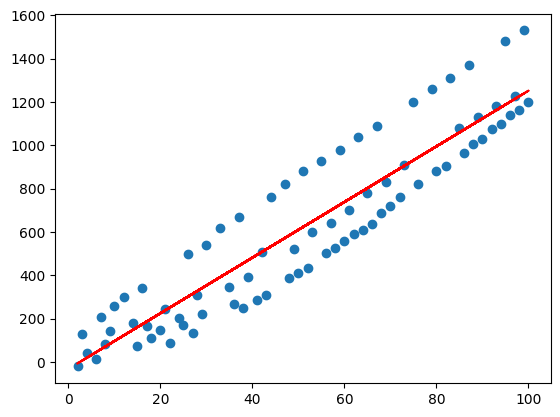

In [22]:
import matplotlib.pyplot as plt
plt.scatter(x_train,y_train)

plt.plot(x_train,ridge.predict(x_train),color='r')

In [23]:
rr = simple_ridge(alpha=100)
rr.fit(x_train,y_train)

w : [12.83490333]
b : [-31.45624729]


In [24]:
r2_score(y_test,rr.predict(x_test))


0.8288118327429005

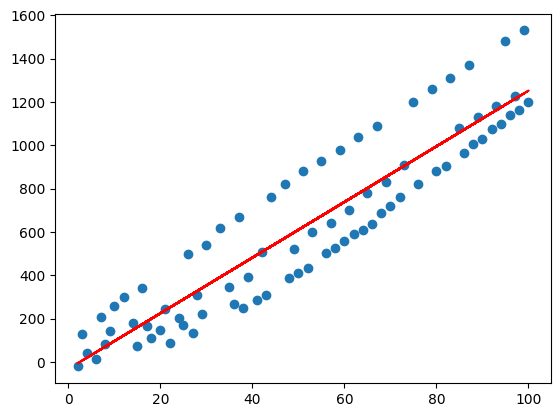

In [25]:
import matplotlib.pyplot as plt
plt.scatter(x_train,y_train)

plt.plot(x_train,rr.predict(x_train),color='r')